# **Machine Learning: Advanced Fraud Transaction Detection**
**Feature Engineering & Data Validation**
* Ekstraksi Fitur Velocity (Time-Decay)
* Pemetaan Jaringan Fraud (Bipartite Graph Centrality)
* Time-Based Splitting (Mencegah Data Leakage)
----------------------------------------------------
**Advanced Modelling & Business Evaluation**
* Klasifikasi LightGBM (Native Categorical Handling)
* Evaluasi Metrik Data Imbalanced (PR-AUC)
* Threshold Tuning untuk Optimasi Trade-off Bisnis

>**Aisyah Amalia Hamid @ mal-lia**

# **Dataset IEEE-CIS Fraud Detection (Kaggle Competition)**

### **Setup Environment & Install Libraries**

In [1]:
!pip install -q networkx kaggle

In [2]:
!pip install --upgrade kaggle

### **Import Semua Library**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import networkx as nx
import gc
import os
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Colab_Fraud")

### **Load Dataset**

In [4]:
!export KAGGLE_API_TOKEN=KGAT_ef0854da35580bc33289abd43ebe71f1

In [5]:
!mkdir -p ~/.kaggle && echo KGAT_ef0854da35580bc33289abd43ebe71f1 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [6]:
!kaggle competitions download -c ieee-fraud-detection

100% 118M/118M [00:01<00:00, 118MB/s]



In [7]:
!unzip -q ieee-fraud-detection.zip -d /content/data/

# Training Data Paths
TRAIN_TRANS_PATH = '/content/data/train_transaction.csv'
TRAIN_IDENTITY_PATH = '/content/data/train_identity.csv'

# Test Data Paths
TEST_TRANS_PATH = '/content/data/test_transaction.csv'
TEST_IDENTITY_PATH = '/content/data/test_identity.csv'

### **Explorary Data Analysis (EDA) Data Testing**

In [8]:
df_trans_sample = pd.read_csv(TEST_TRANS_PATH, nrows=10000)
df_id_sample = pd.read_csv(TEST_IDENTITY_PATH, nrows=10000)

In [9]:
print("Info Transaction:")
df_trans_sample.info()

Info Transaction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 393 entries, TransactionID to V339
dtypes: float64(376), int64(3), object(14)
memory usage: 30.0+ MB


In [10]:
print("5 Baris Pertama Transaction:")
display(df_trans_sample.head())

5 Baris Pertama Transaction:


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("Statistik Deskriptif (Transaction Amount):")
display(df_trans_sample['TransactionAmt'].describe())

Statistik Deskriptif (Transaction Amount):


,TransactionAmt
count,10000.000000
mean,141.004778
std,229.745361
min,0.246000
25%,49.000000
50%,77.000000
75%,144.950000
max,7777.490000


In [12]:
print("Info Identity:")
df_id_sample.info()

Info Identity:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  10000 non-null  int64  
 1   id-01          10000 non-null  float64
 2   id-02          9720 non-null   float64
 3   id-03          5151 non-null   float64
 4   id-04          5151 non-null   float64
 5   id-05          9488 non-null   float64
 6   id-06          9488 non-null   float64
 7   id-07          353 non-null    float64
 8   id-08          353 non-null    float64
 9   id-09          5624 non-null   float64
 10  id-10          5624 non-null   float64
 11  id-11          9712 non-null   float64
 12  id-12          10000 non-null  object 
 13  id-13          9332 non-null   float64
 14  id-14          4702 non-null   float64
 15  id-15          9721 non-null   object 
 16  id-16          8757 non-null   object 
 17  id-17          9612 non-null   float

In [13]:
print("5 Baris Pertama Identity:")
display(df_id_sample.head())

5 Baris Pertama Identity:


,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW


In [14]:
df_test = pd.merge(df_trans_sample, df_id_sample, on='TransactionID', how='left')
print("Info Gabungan Data Test:")
df_test.info()

print("\n5 Baris Pertama Gabungan Data Test:")
display(df_test.head())

Info Gabungan Data Test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), object(31)
memory usage: 33.0+ MB

5 Baris Pertama Gabungan Data Test:


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


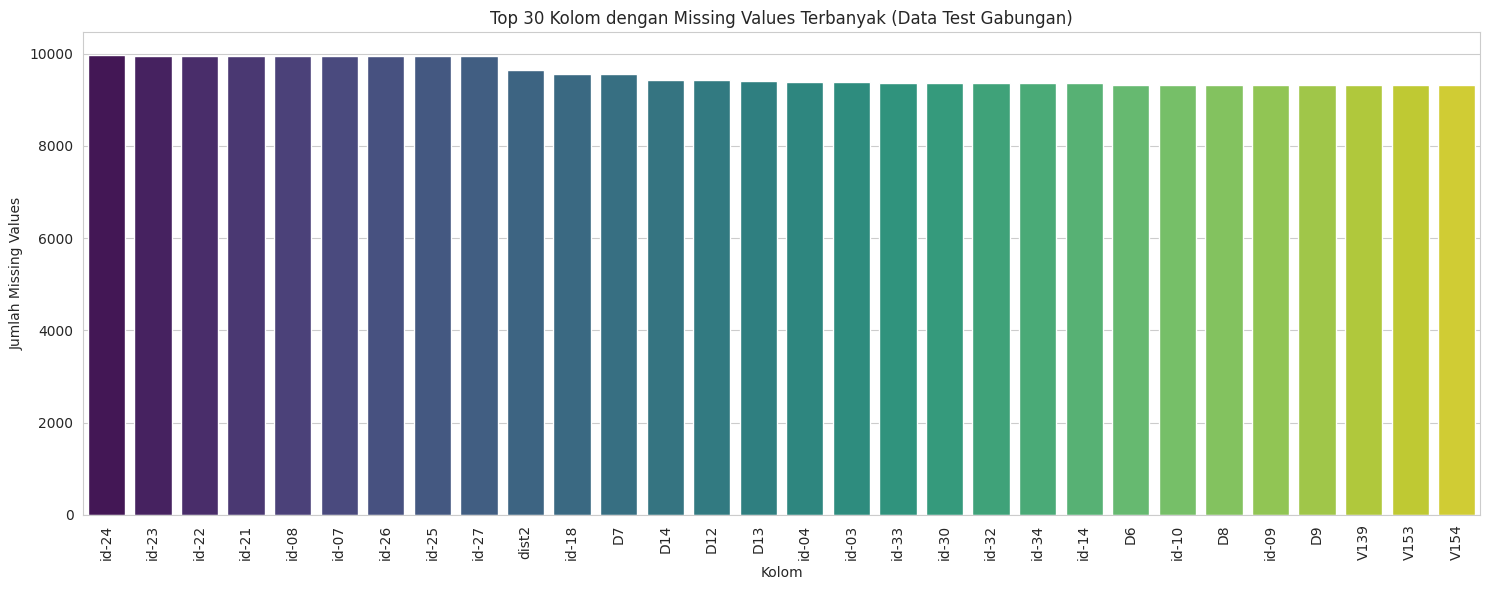

In [15]:
missing_data = df_test.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=missing_data.index[:30], y=missing_data.values[:30], hue=missing_data.index[:30], palette='viridis', legend=False)
plt.title('Top 30 Kolom dengan Missing Values Terbanyak (Data Test Gabungan)')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

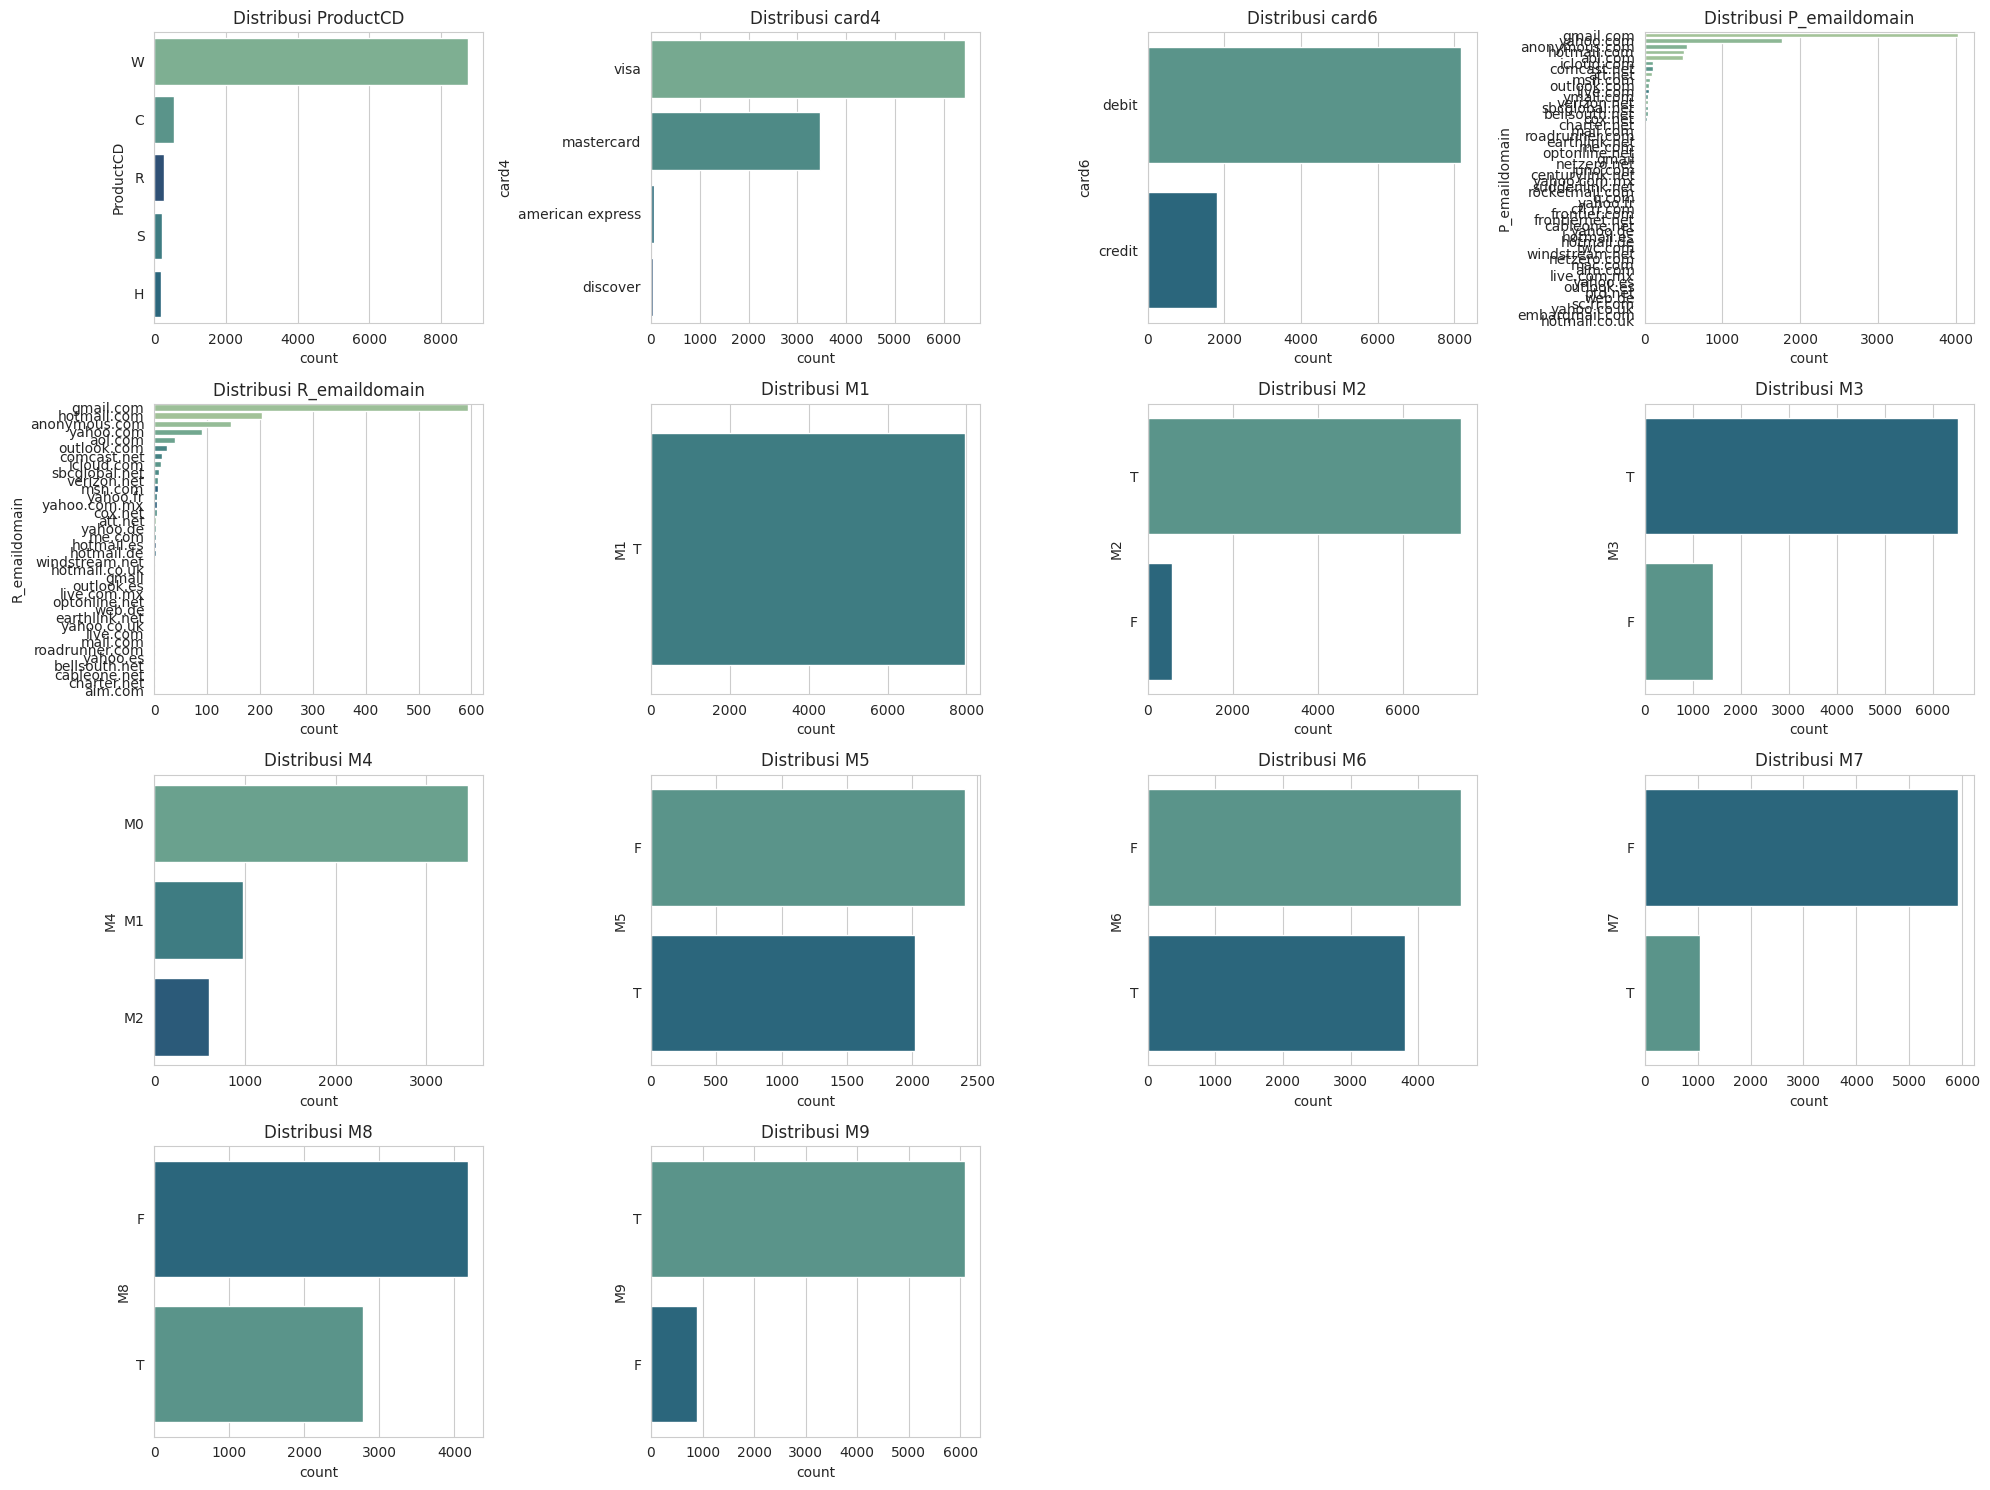

In [16]:
categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    if col in df_test.columns:
        plt.subplot(4, 4, i + 1)
        sns.countplot(y=df_test[col], order=df_test[col].value_counts().index, hue=df_test[col], palette='crest', legend=False)
        plt.title(f'Distribusi {col}')
        plt.tight_layout()
plt.show()

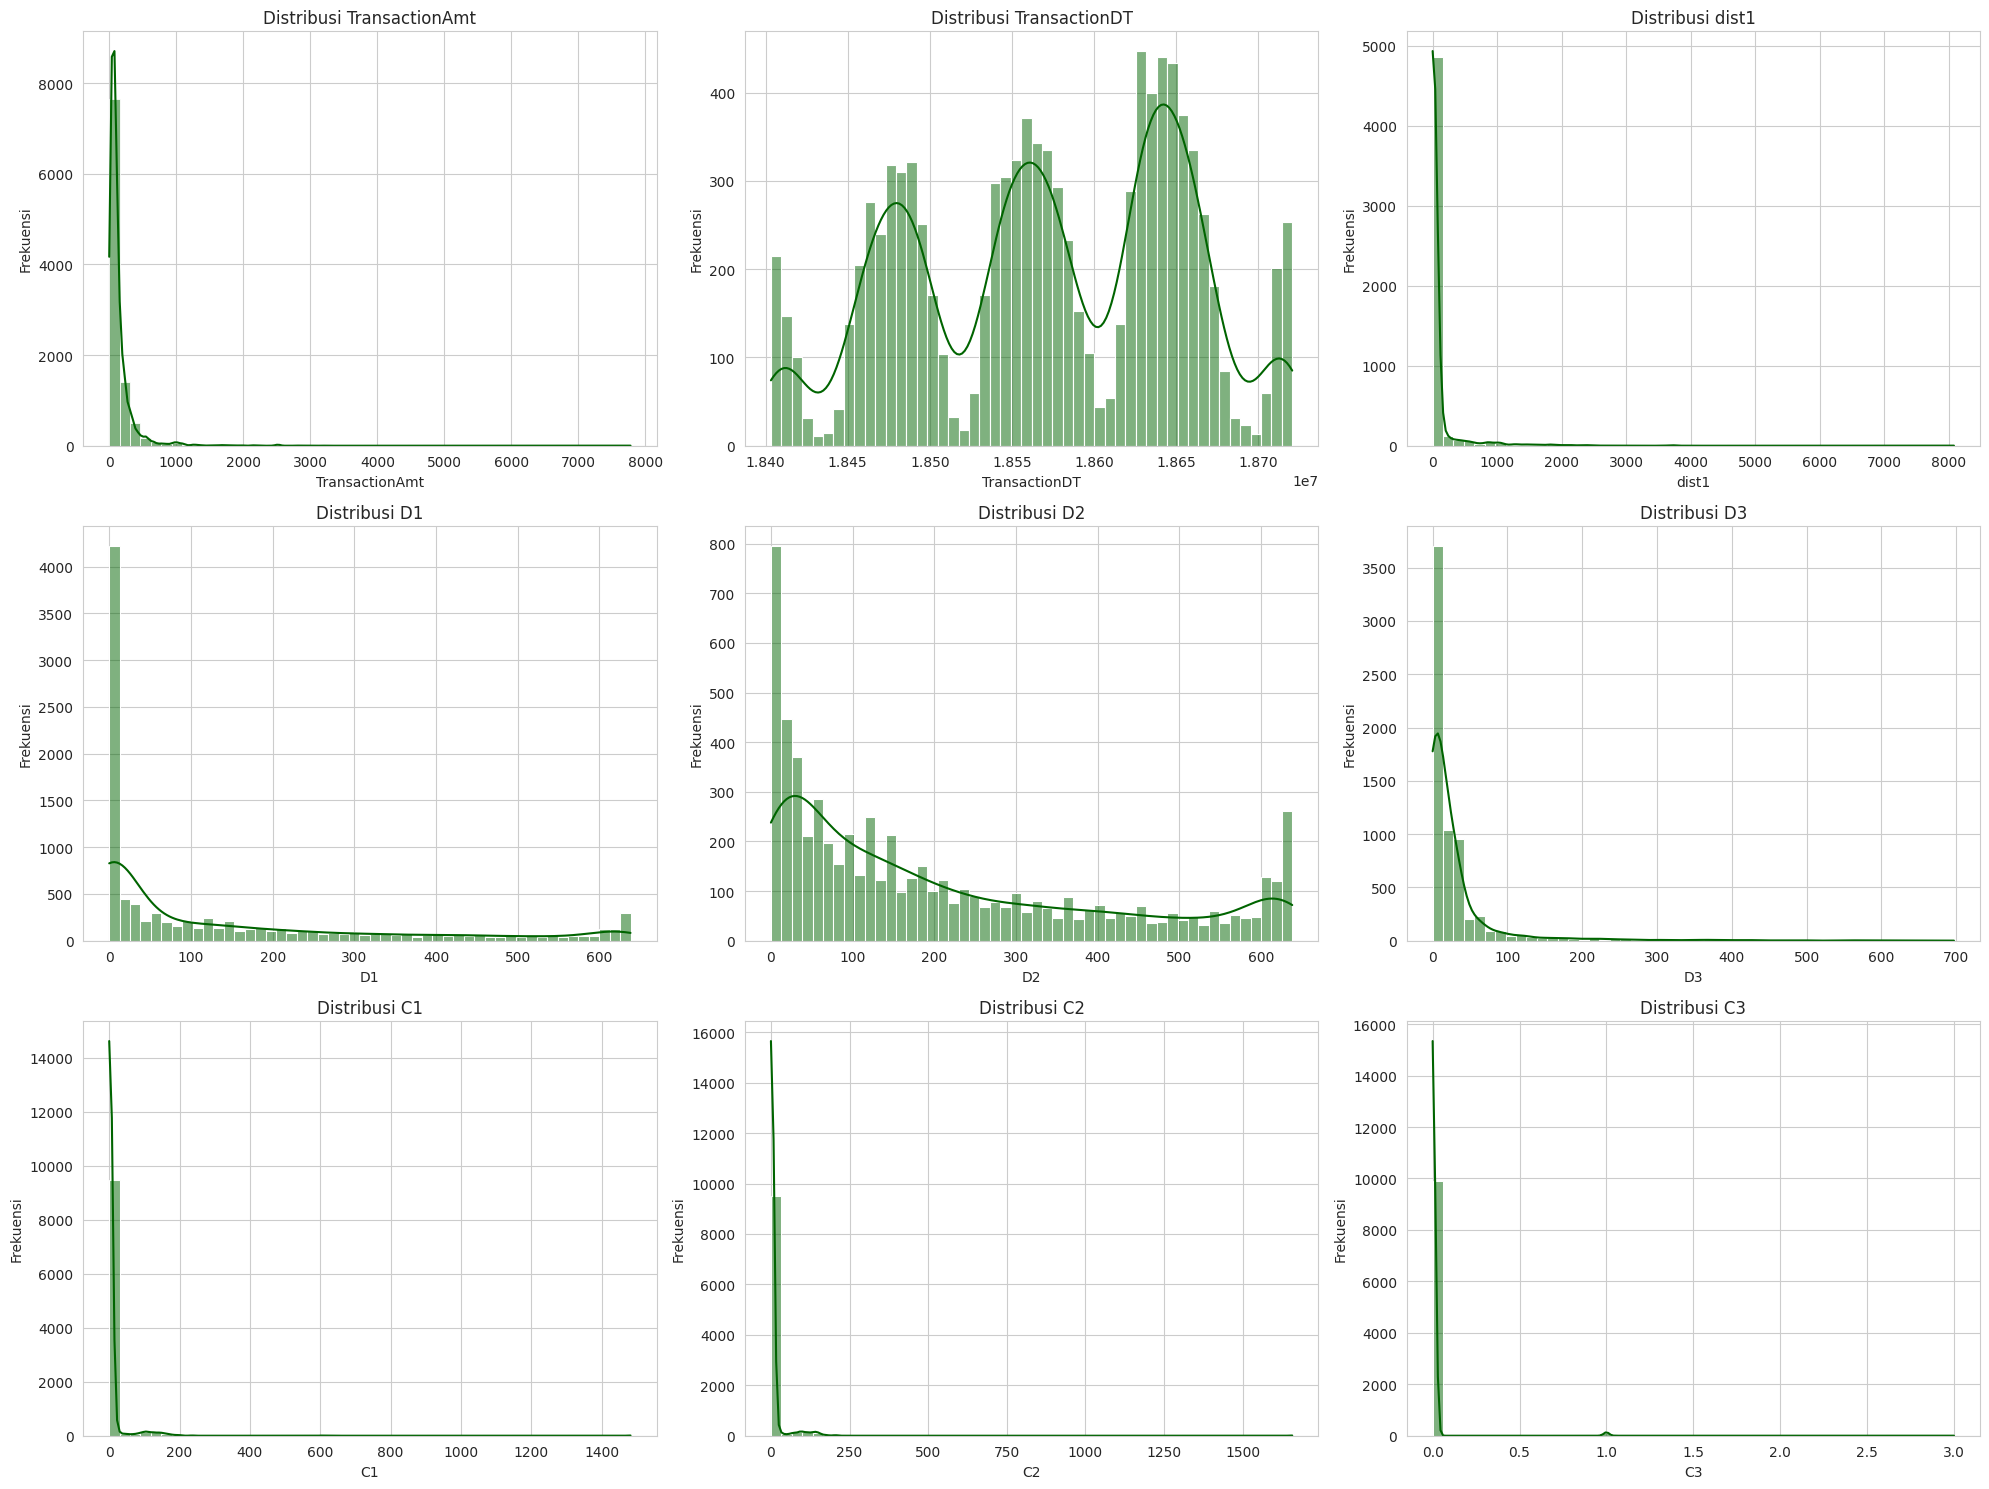

In [17]:
numerical_cols_to_plot = ['TransactionAmt', 'TransactionDT', 'dist1', 'D1', 'D2', 'D3', 'C1', 'C2', 'C3']

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_to_plot):
    if col in df_test.columns:
        plt.subplot(3, 3, i + 1)
        sns.histplot(df_test[col].dropna(), bins=50, kde=True, color='darkgreen')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.ylabel('Frekuensi')
        plt.tight_layout()
plt.show()

### **Exploratory Data Analysis (EDA) Data Training**

In [18]:
df_train_trans = pd.read_csv(TRAIN_TRANS_PATH, nrows=10000)
df_train_id = pd.read_csv(TRAIN_IDENTITY_PATH, nrows=10000)

print("Info Transaction Training:")
df_train_trans.info()

Info Transaction Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 30.1+ MB


In [19]:
print("5 Baris Pertama Transaction Training:")
display(df_train_trans.head())

5 Baris Pertama Transaction Training:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
print("Info Identity Training:")
df_train_id.info()

Info Identity Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  10000 non-null  int64  
 1   id_01          10000 non-null  float64
 2   id_02          9750 non-null   float64
 3   id_03          4579 non-null   float64
 4   id_04          4579 non-null   float64
 5   id_05          9479 non-null   float64
 6   id_06          9479 non-null   float64
 7   id_07          359 non-null    float64
 8   id_08          359 non-null    float64
 9   id_09          5394 non-null   float64
 10  id_10          5394 non-null   float64
 11  id_11          9750 non-null   float64
 12  id_12          10000 non-null  object 
 13  id_13          7723 non-null   float64
 14  id_14          6992 non-null   float64
 15  id_15          9750 non-null   object 
 16  id_16          9187 non-null   object 
 17  id_17          9664 non-nul

In [21]:
print("5 Baris Pertama Identity Training:")
display(df_train_id.head())

5 Baris Pertama Identity Training:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [22]:
df_train = pd.merge(df_train_trans, df_train_id, on='TransactionID', how='left')
print("Info Gabungan Data Training:")
df_train.info()

print("\n5 Baris Pertama Gabungan Data Training:")
display(df_train.head())

Info Gabungan Data Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 33.1+ MB

5 Baris Pertama Gabungan Data Training:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Cek Imbalance Target (isFraud):
Persentase Fraud dalam sample training: 2.6500% (Sangat Imbalanced!)


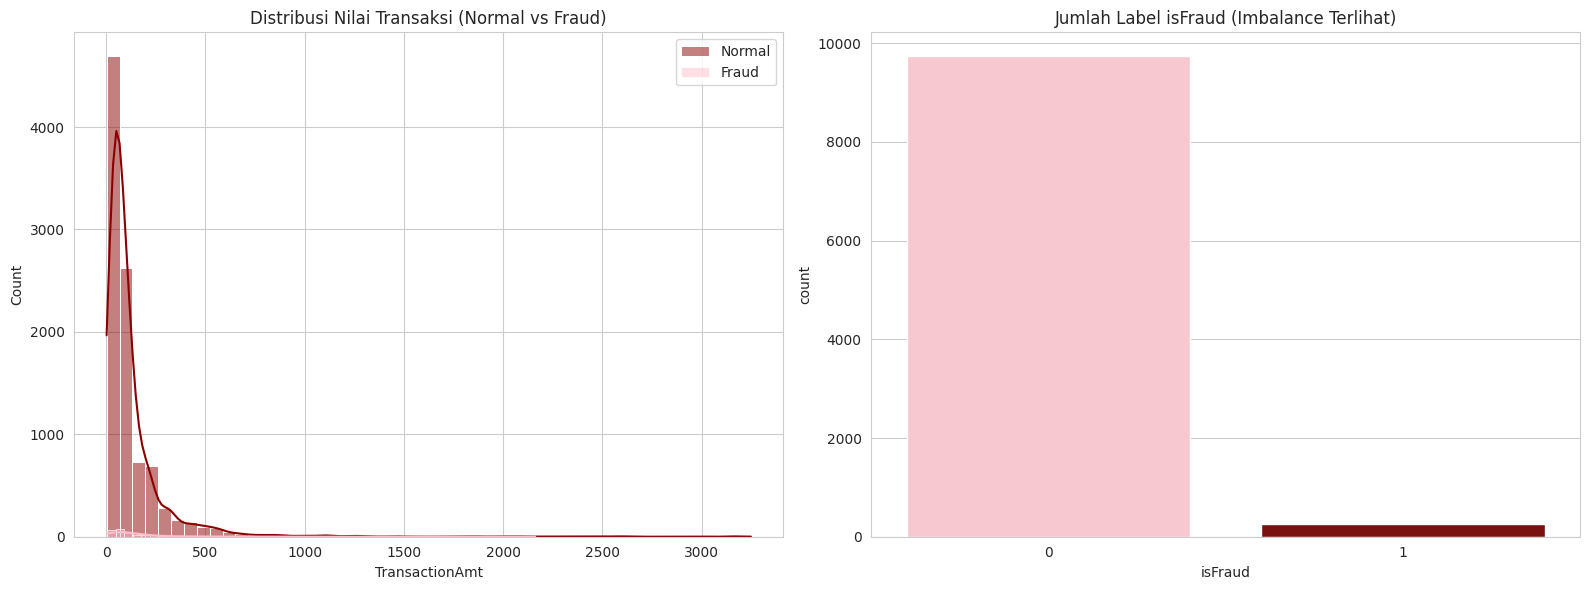

In [23]:
print("Cek Imbalance Target (isFraud):")
fraud_ratio = df_train['isFraud'].mean() * 100
print(f"Persentase Fraud dalam sample training: {fraud_ratio:.4f}% (Sangat Imbalanced!)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_train[df_train['isFraud']==0]['TransactionAmt'], bins=50, label='Normal', color='darkred', ax=axes[0], kde=True)
sns.histplot(df_train[df_train['isFraud']==1]['TransactionAmt'], bins=50, label='Fraud', color='pink', ax=axes[0], kde=True)
axes[0].set_title('Distribusi Nilai Transaksi (Normal vs Fraud)')
axes[0].legend()
sns.countplot(x='isFraud', data=df_train, ax=axes[1], hue='isFraud', palette=['pink', 'darkred'], legend=False)
axes[1].set_title('Jumlah Label isFraud (Imbalance Terlihat)')
plt.tight_layout()
plt.show()

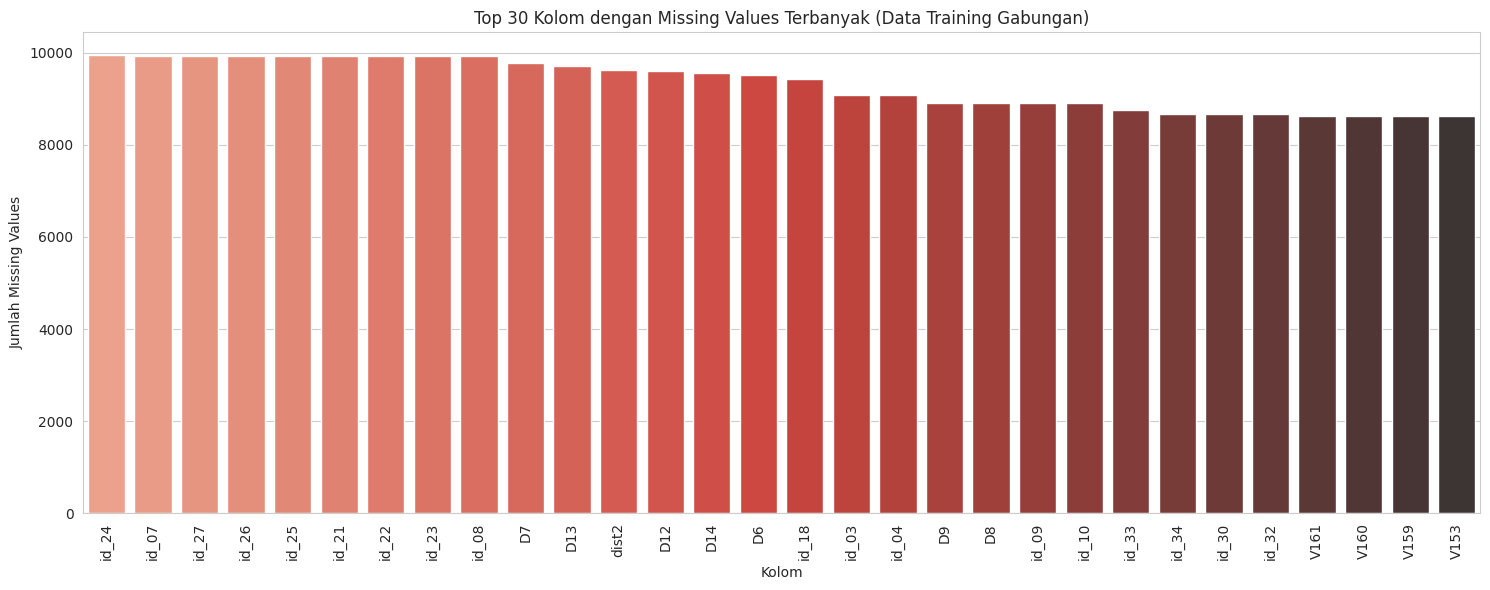

In [24]:
missing_data_train = df_train.isnull().sum()
missing_data_train = missing_data_train[missing_data_train > 0].sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=missing_data_train.index[:30], y=missing_data_train.values[:30], hue=missing_data_train.index[:30], palette='Reds_d', legend=False)
plt.title('Top 30 Kolom dengan Missing Values Terbanyak (Data Training Gabungan)')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

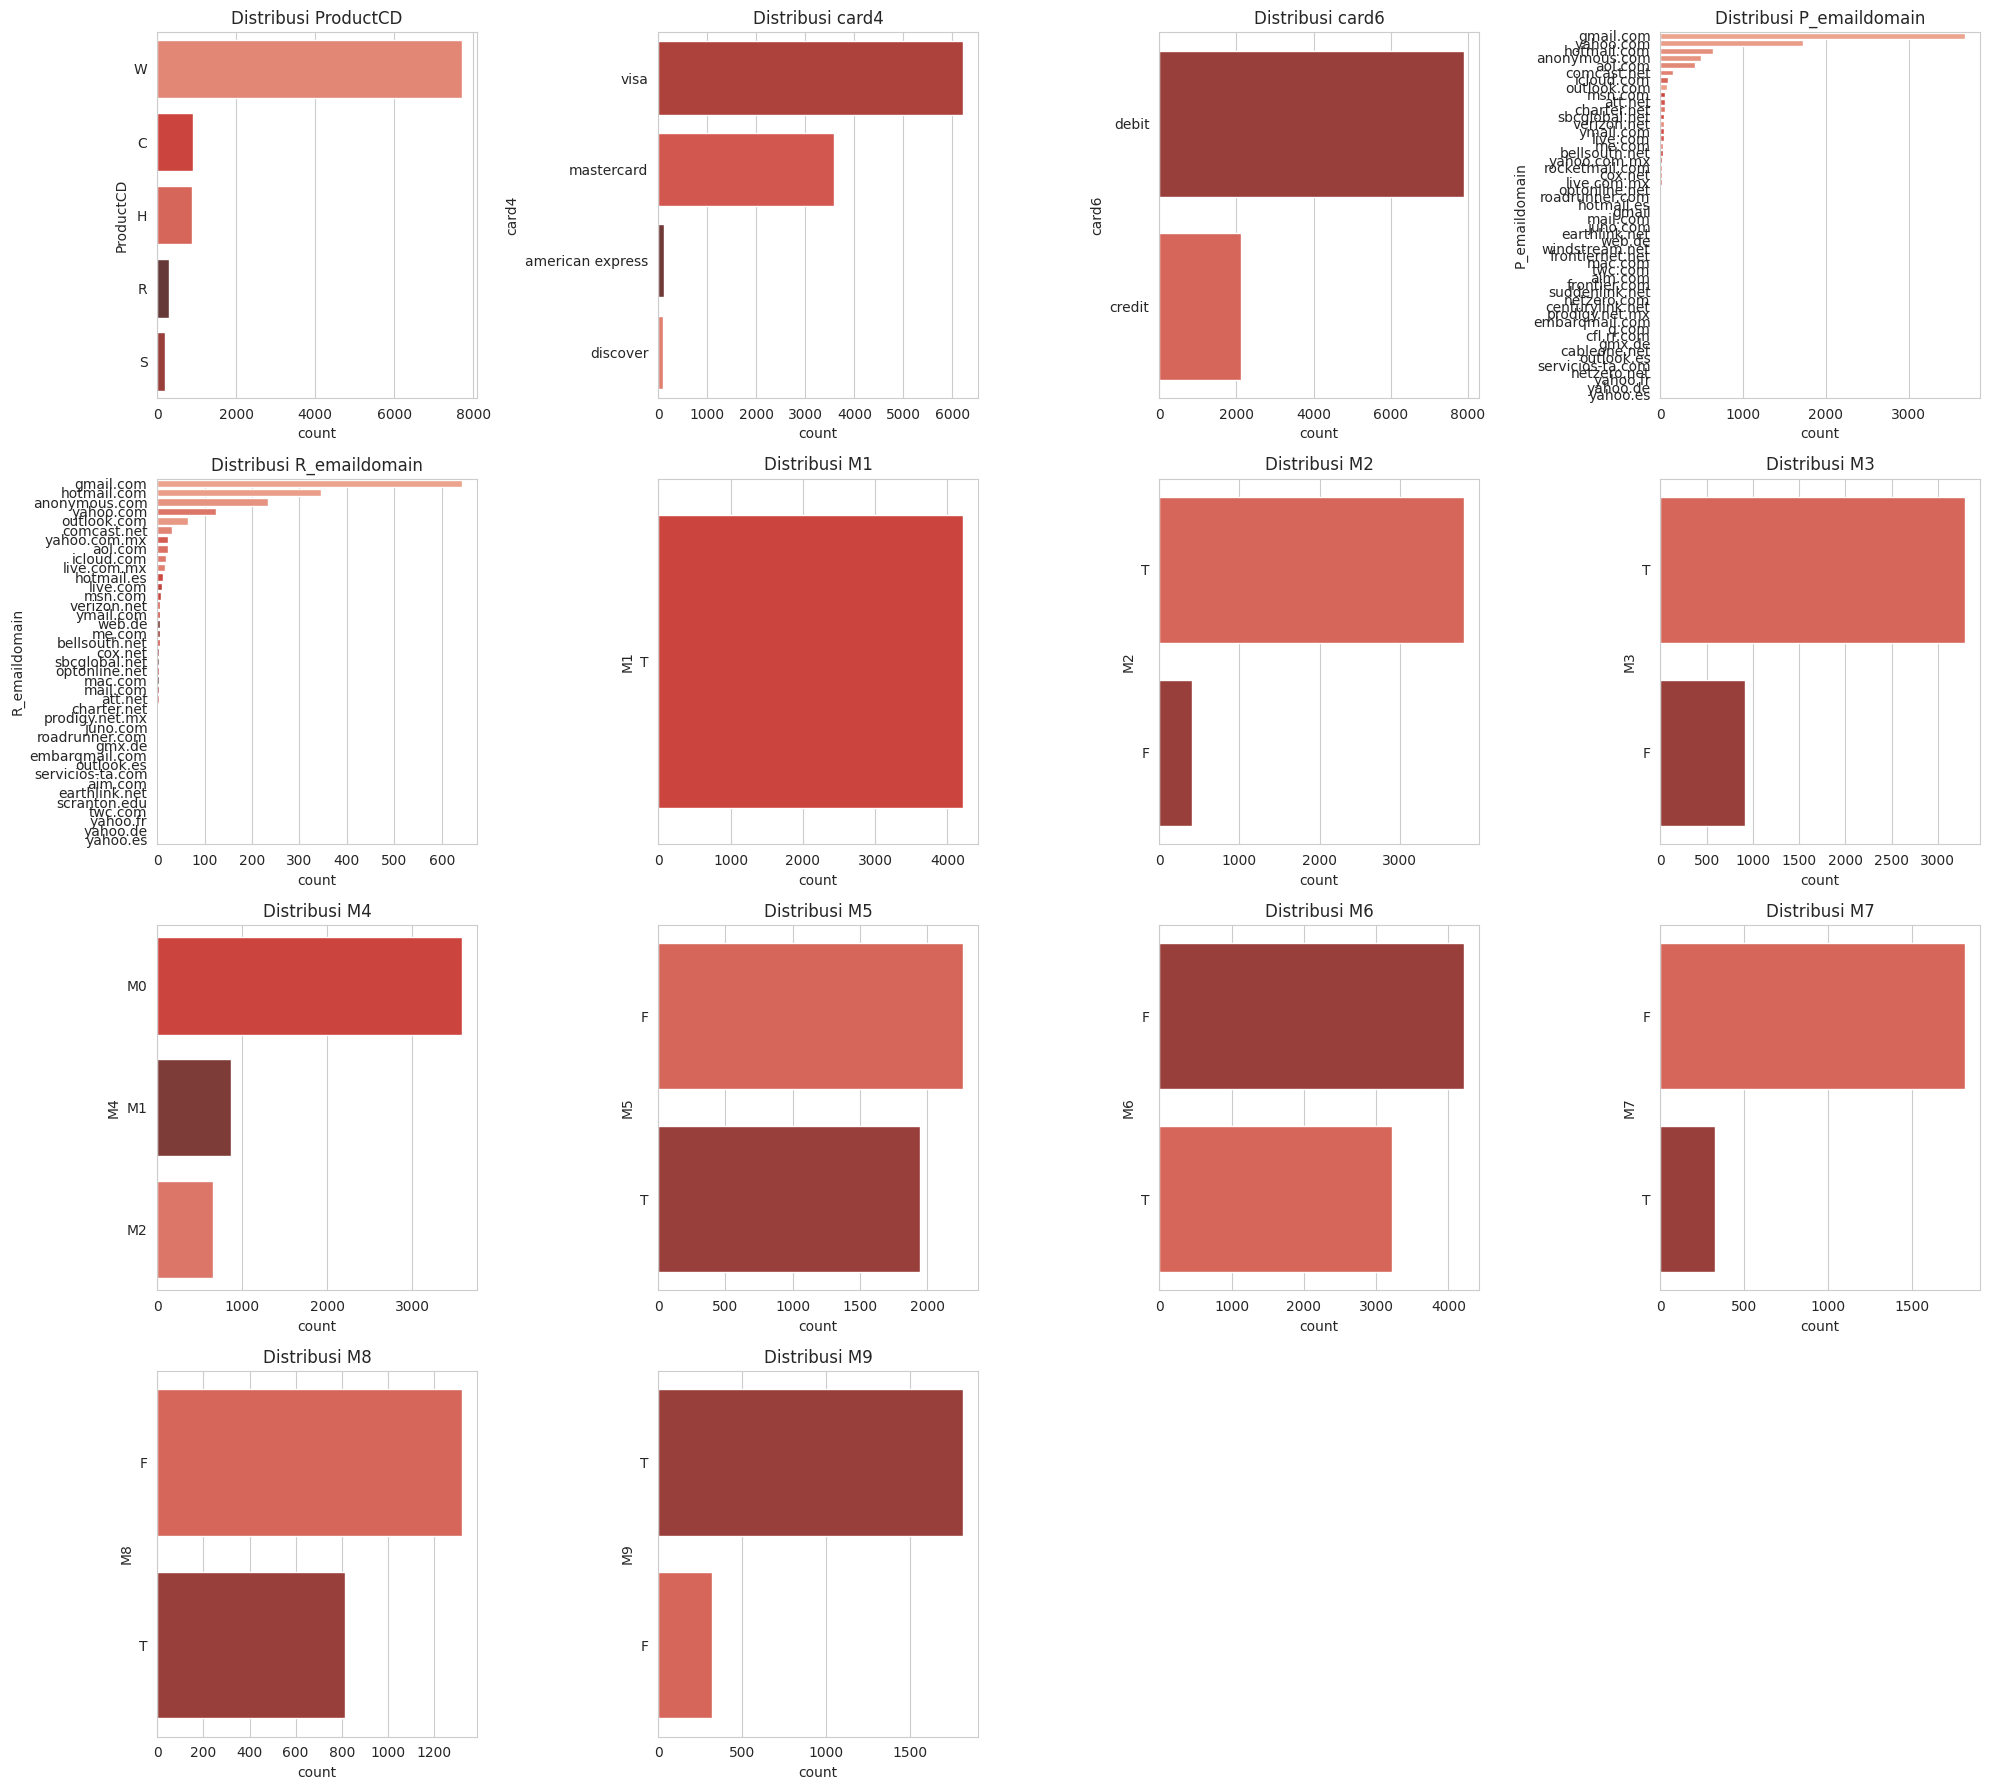

In [25]:
categorical_cols_train = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

plt.figure(figsize=(20, 18))
for i, col in enumerate(categorical_cols_train):
    if col in df_train.columns:
        plt.subplot(4, 4, i + 1)
        sns.countplot(y=df_train[col], order=df_train[col].value_counts().index, hue=df_train[col], palette='Reds_d', legend=False)
        plt.title(f'Distribusi {col}')
        plt.tight_layout()
plt.show()

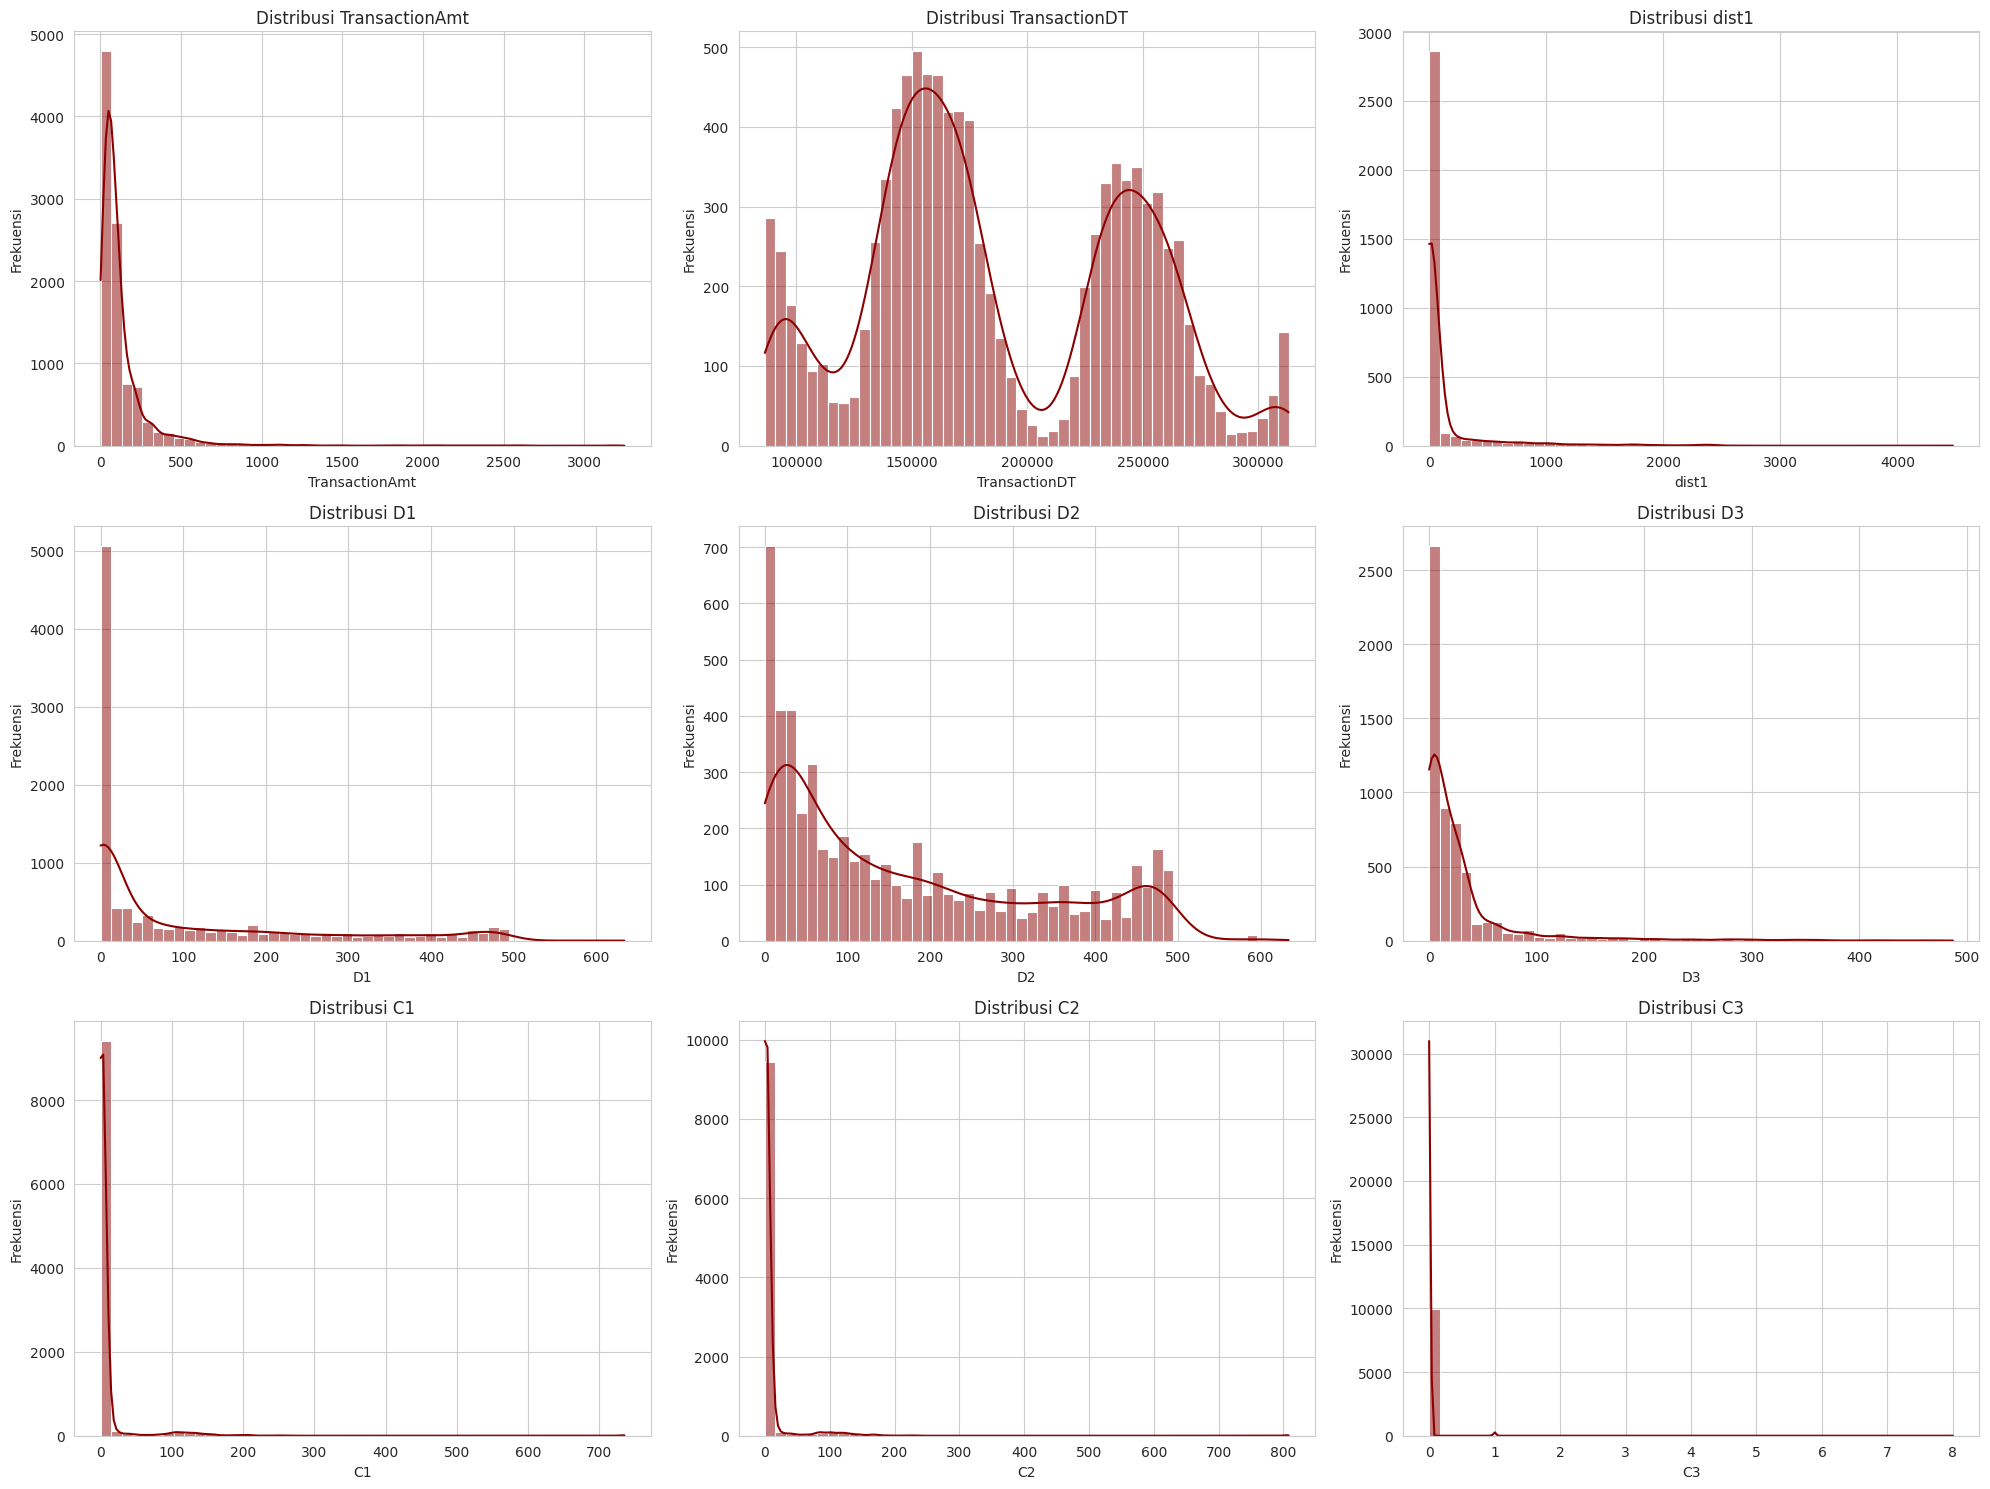

In [26]:
numerical_cols_to_plot_train = ['TransactionAmt', 'TransactionDT', 'dist1', 'D1', 'D2', 'D3', 'C1', 'C2', 'C3']

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_to_plot_train):
    if col in df_train.columns:
        plt.subplot(3, 3, i + 1)
        sns.histplot(df_train[col].dropna(), bins=50, kde=True, color='darkred')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.ylabel('Frekuensi')
        plt.tight_layout()
plt.show()

## **IEEE Fraud Pipeline untuk Data Training**

In [27]:
class IEEEFraudPipeline:
    def __init__(self, transaction_path: str, identity_path: str):
        self.transaction_path = transaction_path
        self.identity_path = identity_path
        self.df = pd.DataFrame()

    def reduce_mem_usage(self, df: pd.DataFrame) -> pd.DataFrame:
        start_mem = df.memory_usage().sum() / 1024**2
        logger.info(f'💾 Memory awal: {start_mem:.2f} MB')

        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
                else:
                    if col == 'TransactionAmt':
                        df[col] = df[col].astype(np.float32) # Ensure at least float32
                    elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        df[col] = df[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)

        end_mem = df.memory_usage().sum() / 1024**2
        logger.info(f'💾 Memory akhir: {end_mem:.2f} MB (Turun {(start_mem - end_mem)/start_mem*100:.1f}%)')
        return df

    def load_and_merge(self) -> None:
        logger.info("📂 Memuat & Menggabungkan Transaction dan Identity...")
        df_trans = pd.read_csv(self.transaction_path)
        df_id = pd.read_csv(self.identity_path)
        self.df = df_trans.merge(df_id, on='TransactionID', how='left')
        if 'isFraud' in df_trans.columns:
            self.df['isFraud'] = df_trans['isFraud']
        del df_trans, df_id
        gc.collect()
        self.df = self.reduce_mem_usage(self.df)

    def extract_time_features(self) -> None:
        logger.info("⏳ Ekstraksi fitur waktu (Hour & Day)...")
        self.df['Transaction_Hour'] = np.floor((self.df['TransactionDT'] / 3600) % 24)
        self.df['Transaction_Day'] = np.floor((self.df['TransactionDT'] / (3600 * 24) - 1) % 7)

    def generate_velocity_features(self) -> None:
        logger.info("🚀 Membangun Velocity Features (Kecepatan transaksi per kartu)...")
        if 'card1' in self.df.columns and self.df['card1'].dtype == 'object':
            self.df['card1'] = pd.to_numeric(self.df['card1'], errors='coerce')
        self.df = self.df.sort_values(by=['card1', 'TransactionDT'])
        self.df['time_since_last_txn_card'] = self.df.groupby('card1')['TransactionDT'].diff().fillna(-1)
        self.df['card1_daily_count'] = self.df.groupby(['card1', 'Transaction_Day'])['TransactionID'].transform('count')

    def generate_network_features(self) -> None:
        logger.info("🕸️ Membangun Network Features (Bipartite Graph Kartu-Device)...")
        df_graph = self.df.dropna(subset=['DeviceInfo', 'card1']).copy()
        df_graph['card1'] = df_graph['card1'].astype(str)

        if not df_graph.empty:
            G = nx.from_pandas_edgelist(df_graph, source='card1', target='DeviceInfo')
            centrality = nx.degree_centrality(G)

            self.df['card1_degree'] = self.df['card1'].astype(str).map(centrality).fillna(0)
            self.df['DeviceInfo_degree'] = self.df['DeviceInfo'].map(centrality).fillna(0)
        else:
            self.df['card1_degree'] = 0
            self.df['DeviceInfo_degree'] = 0

    def run_pipeline(self) -> pd.DataFrame:
        self.load_and_merge()
        self.extract_time_features()
        self.generate_velocity_features()
        self.generate_network_features()
        logger.info(f"✅ Pipeline selesai! Data akhir berukuran: {self.df.shape}")
        return self.df

In [28]:
train_pipeline = IEEEFraudPipeline(TRAIN_TRANS_PATH, TRAIN_IDENTITY_PATH)
df_train_processed = train_pipeline.run_pipeline()

/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338526.py:28: RuntimeWarning: overflow encountered in cast
  elif c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_22834/2978338

In [29]:
print("Info Data Training Setelah Pipeline:")
df_train_processed.info()

print("\n5 Baris Pertama Data Training Setelah Pipeline:")
display(df_train_processed.head())

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


Info Data Training Setelah Pipeline:
<class 'pandas.core.frame.DataFrame'>
Index: 590540 entries, 243924 to 115181
Columns: 440 entries, TransactionID to DeviceInfo_degree
dtypes: float16(353), float32(46), float64(5), int16(1), int32(2), int64(1), int8(1), object(31)
memory usage: 678.6+ MB

5 Baris Pertama Data Training Setelah Pipeline:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_37,id_38,DeviceType,DeviceInfo,Transaction_Hour,Transaction_Day,time_since_last_txn_card,card1_daily_count,card1_degree,DeviceInfo_degree
243924,3230924,0,5787419,23.443001,C,1000,555.0,185.0,mastercard,224.0,...,T,F,mobile,F3213 Build/36.0.A.2.146,23.0,2.0,-1.0,1,0.000104,0.001453
36634,3023634,0,916268,183.000000,W,1001,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,14.0,2.0,-1.0,1,0.000000,0.000000
164336,3151336,0,3504180,29.000000,W,1001,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,13.0,4.0,2587912.0,2,0.000000,0.000000
223739,3210739,0,5270458,27.000000,W,1001,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,0.0,4.0,1766278.0,2,0.000000,0.000000
33767,3020767,0,842821,150.000000,R,1004,583.0,150.0,visa,226.0,...,T,F,desktop,MacOS,18.0,1.0,-1.0,3,0.000311,0.237290


### **Visualisasi Data Training**

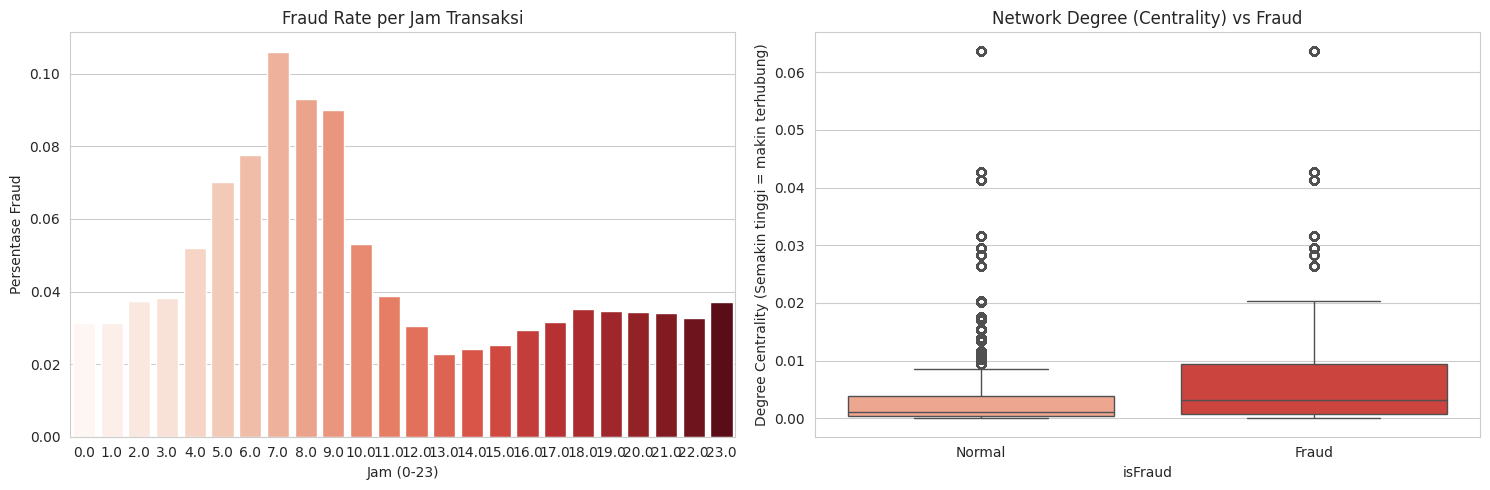

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hourly_fraud = df_train_processed.groupby('Transaction_Hour')['isFraud'].mean()
sns.barplot(x=hourly_fraud.index, y=hourly_fraud.values, ax=axes[0], palette='Reds', hue=hourly_fraud.index, legend=False)
axes[0].set_title('Fraud Rate per Jam Transaksi')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Persentase Fraud')
sns.boxplot(x='isFraud', y='card1_degree', data=df_train_processed, ax=axes[1], palette='Reds', hue='isFraud', legend=False)
axes[1].set_title('Network Degree (Centrality) vs Fraud')
axes[1].set_xticks([0, 1]) # Explicitly set x-ticks
axes[1].set_xticklabels(['Normal', 'Fraud'])
axes[1].set_ylabel('Degree Centrality (Semakin tinggi = makin terhubung)')

plt.tight_layout()
plt.show()

Heatmap Korelasi dengan Target (isFraud):


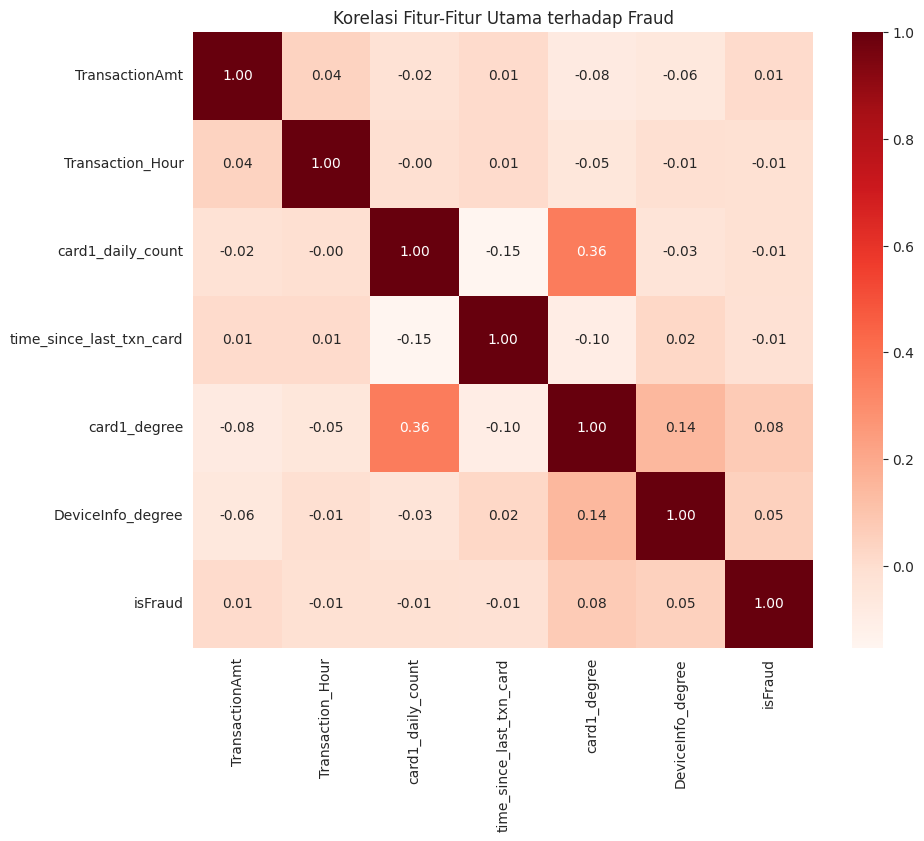

In [32]:
print("Heatmap Korelasi dengan Target (isFraud):")
top_features = ['TransactionAmt', 'Transaction_Hour', 'card1_daily_count', 'time_since_last_txn_card',
                'card1_degree', 'DeviceInfo_degree', 'isFraud']
orr = df_train_processed[top_features].corr()
fig = plt.figure(figsize=(10, 8))
sns.heatmap(orr, annot=True, cmap='Reds', fmt='.2f')
plt.title('Korelasi Fitur-Fitur Utama terhadap Fraud')
plt.show()

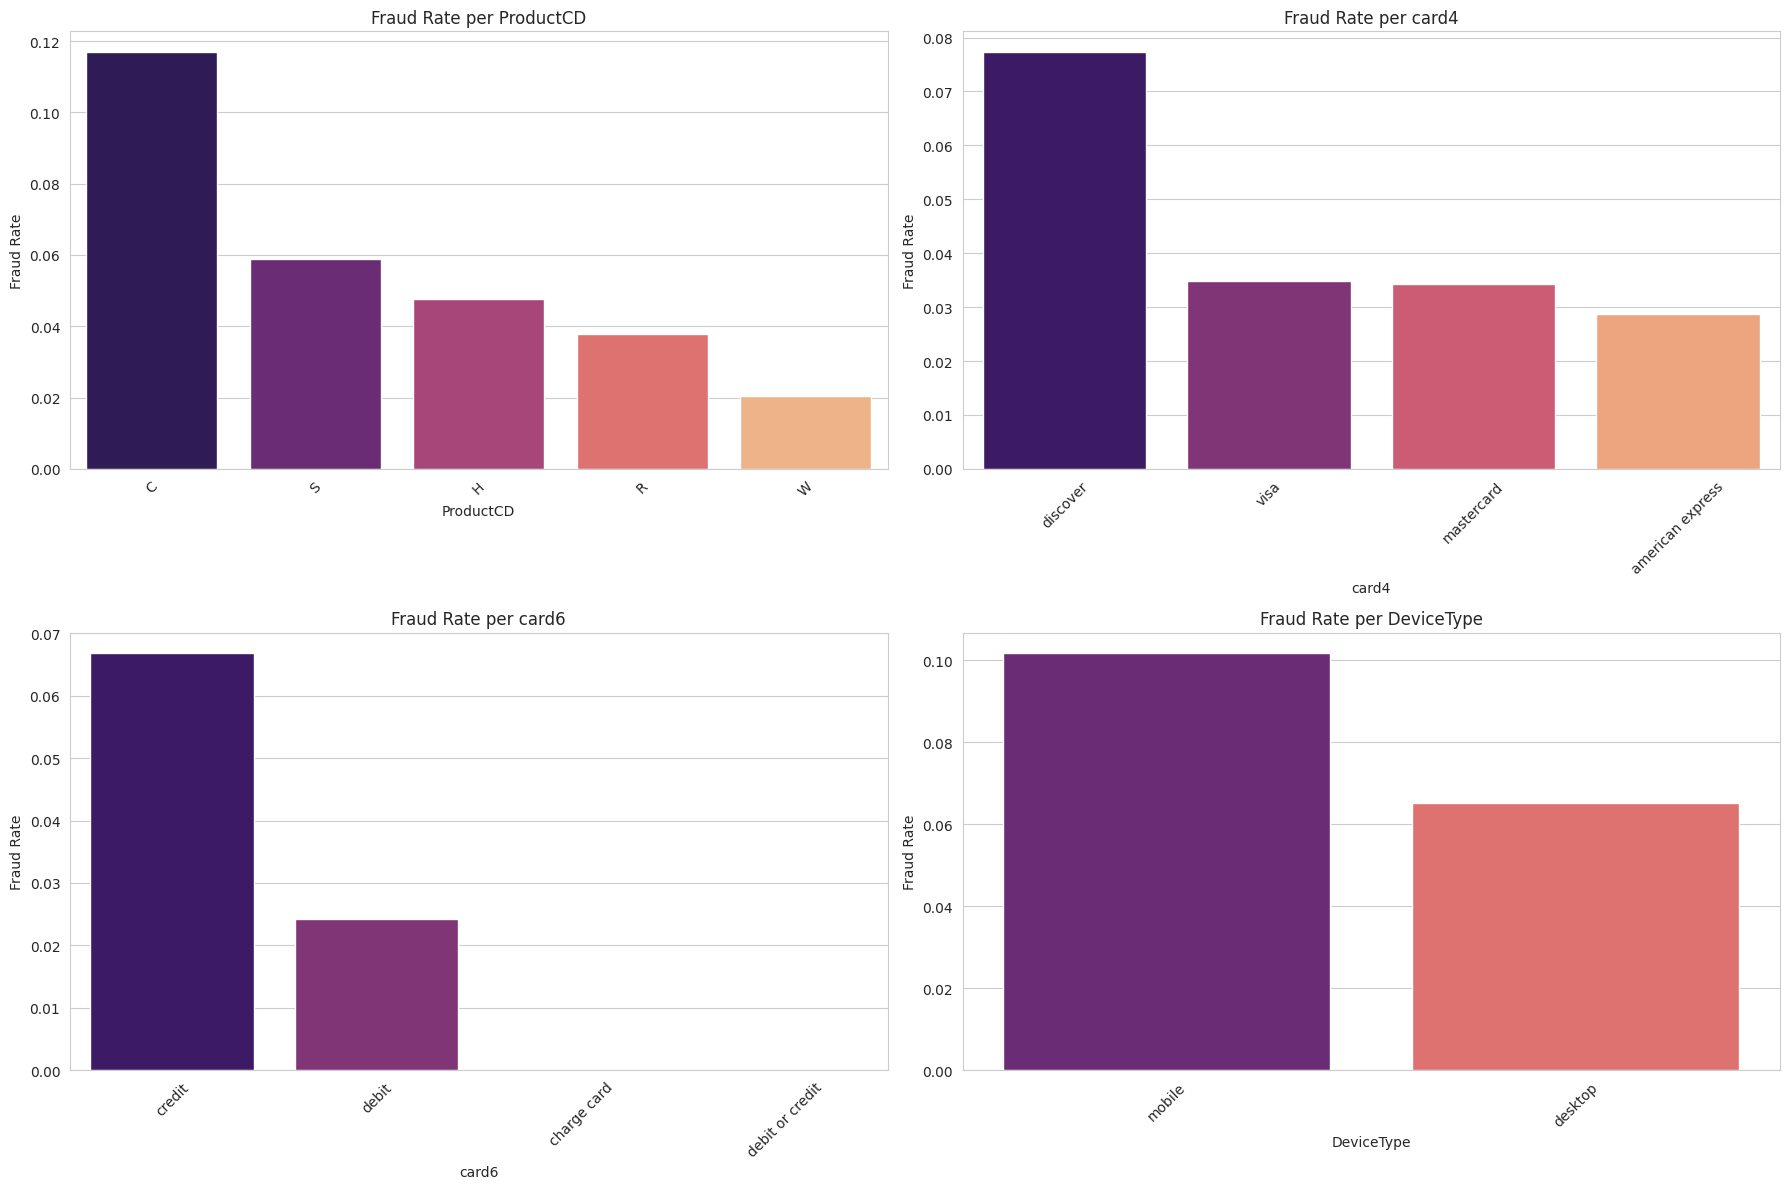

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
categorical_features = ['ProductCD', 'card4', 'card6', 'DeviceType']

for i, feature in enumerate(categorical_features):
    if feature in df_train_processed.columns:
        fraud_rate = df_train_processed.groupby(feature)['isFraud'].mean().sort_values(ascending=False)
        sns.barplot(x=fraud_rate.index, y=fraud_rate.values, ax=axes[i], palette='magma', hue=fraud_rate.index, legend=False)
        axes[i].set_title(f'Fraud Rate per {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Fraud Rate')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Modelling [Baseline] untuk Validasi Training Dataset**

In [45]:
!pip install -q lightgbm

In [46]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
logger.info("Mempersiapkan fitur kategorikal dan numerikal...")

for col in df_train_processed.columns:
    if df_train_processed[col].dtype == 'object':
        df_train_processed[col] = df_train_processed[col].astype('category')

drop_cols = ['TransactionID', 'TransactionDT', 'isFraud']
feature_cols = [col for col in df_train_processed.columns if col not in drop_cols]

logger.info(f"Total fitur yang digunakan: {len(feature_cols)} fitur (Termasuk Kategorikal!)")
logger.info("Melakukan Time-Based Splitting (Mencegah kebocoran masa depan)...")
df_train_processed = df_train_processed.sort_values('TransactionDT').reset_index(drop=True)

X = df_train_processed[feature_cols]
y = df_train_processed['isFraud']
split_index = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

logger.info(f"Ukuran Data Train: {X_train.shape}, Data Test: {X_test.shape}")

logger.info("Melatih model LightGBM...")
model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_custom  = (y_proba >= 0.7).astype(int)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.786344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35214
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 435
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [51]:
print("REPORT: THRESHOLD DEFAULT (0.5) - Agresif Menangkap Fraud")
print(classification_report(y_test, y_pred_default))

print("\nREPORT: THRESHOLD CUSTOM (0.7) - Fokus Mengurangi Salah Blokir")
print(classification_report(y_test, y_pred_custom))

pr_auc = average_precision_score(y_test, y_proba)
print(f"PR-AUC Score Akhir: {pr_auc:.4f}")

REPORT: THRESHOLD DEFAULT (0.5) - Agresif Menangkap Fraud
              precision    recall  f1-score   support

           0       0.99      0.90      0.94    171037
           1       0.21      0.72      0.33      6125

    accuracy                           0.90    177162
   macro avg       0.60      0.81      0.64    177162
weighted avg       0.96      0.90      0.92    177162


REPORT: THRESHOLD CUSTOM (0.7) - Fokus Mengurangi Salah Blokir
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    171037
           1       0.38      0.55      0.45      6125

    accuracy                           0.95    177162
   macro avg       0.68      0.76      0.71    177162
weighted avg       0.96      0.95      0.96    177162

PR-AUC Score Akhir: 0.5058


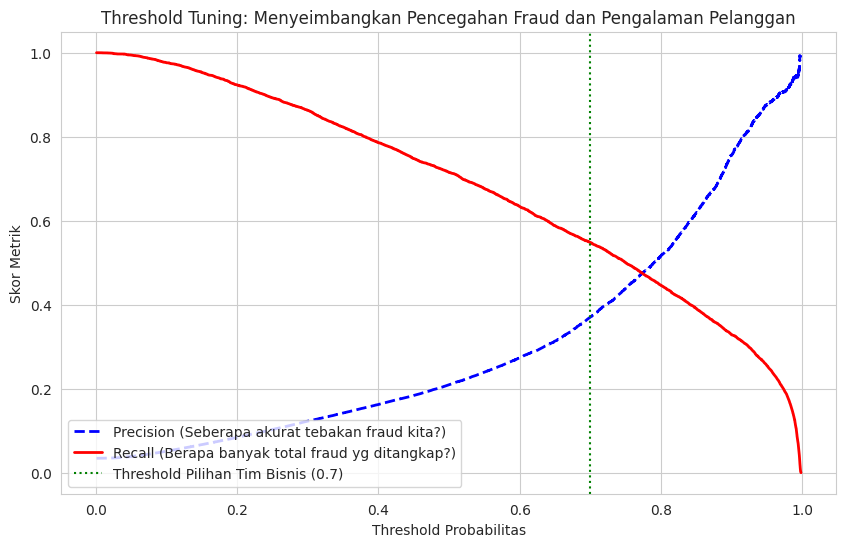

In [48]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Seberapa akurat tebakan fraud kita?)', lw=2)
plt.plot(thresholds, recall[:-1], 'r-', label='Recall (Berapa banyak total fraud yg ditangkap?)', lw=2)
plt.axvline(x=0.7, color='green', linestyle=':', label='Threshold Pilihan Tim Bisnis (0.7)')
plt.xlabel('Threshold Probabilitas')
plt.ylabel('Skor Metrik')
plt.title('Threshold Tuning: Menyeimbangkan Pencegahan Fraud dan Pengalaman Pelanggan')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

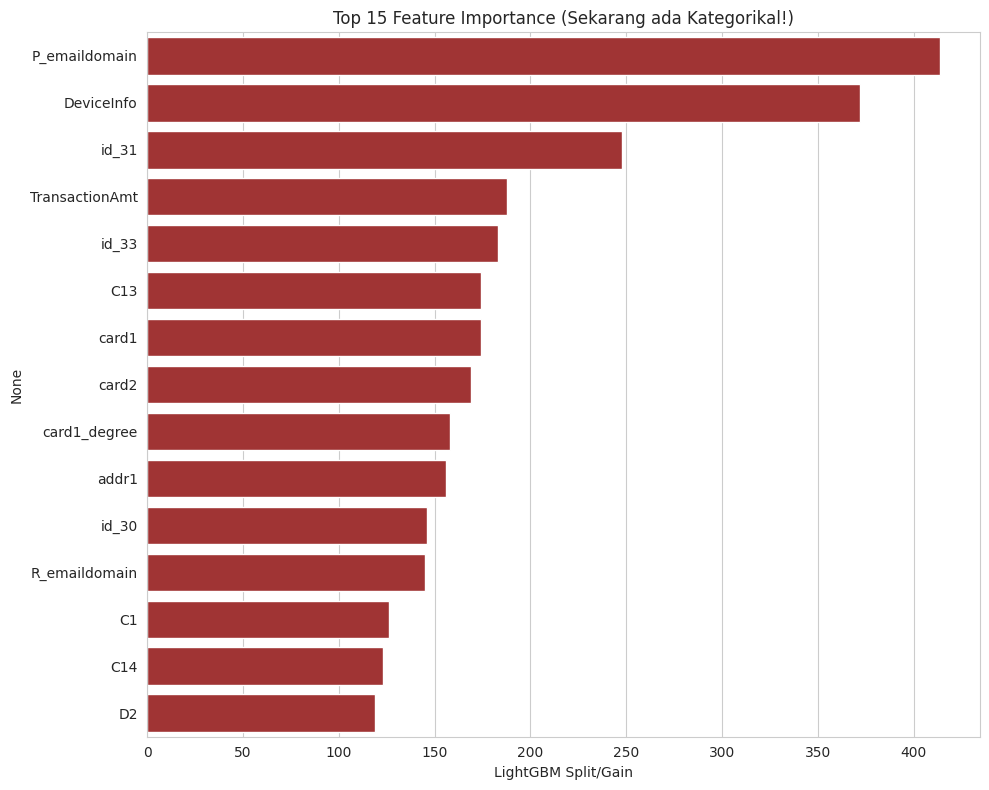

In [49]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importance.values[:15], y=importance.index[:15], color='firebrick')
plt.title('Top 15 Feature Importance (Sekarang ada Kategorikal!)')
plt.xlabel('LightGBM Split/Gain')
plt.tight_layout()
plt.show()